In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold

### Load Dataset

In [ ]:
# # run this block if you run this on colab/kaggle

# import zipfile
# from pathlib import Path

# if not Path('/content/flopwd_data').exists():
#     !gdown -q 114xnPVZtthHi4Bejzho33vGJSqb4-F8g -O /content/dataset.zip
#     with zipfile.ZipFile("/content/dataset.zip") as z:
#         z.extractall("/content/flopwd_data")
# ROOT = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)")
# IMAGES_DIR = ROOT / "Raw_Images"

In [ ]:
from pathlib import Path

ROOT = Path("../../data") # uses Path() to avoid errors on IMAGE_DIR detected as string
IMAGES_DIR = ROOT / "Raw_Images"
SEED = 42

### Data Preprocessing

In [4]:
labels_df = pd.read_csv(ROOT / "Image_labels_Binary Classification Task.csv")

labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [5]:
reg_df = pd.read_csv(ROOT / "Mask_foreground_percentages_Regression Task.csv")

reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


merge

In [6]:
df = labels_df.merge(reg_df, on="image name", how="inner")

df.head()

,image name,Presence of plastic waste?,plastic waste accumulation (in percentage)
0,img1.jpg,yes,0.08
1,img2.jpg,yes,0.03
2,img3.jpg,yes,0.38
3,img4.jpg,yes,0.20
4,img5.jpg,yes,0.18


Renaming some columns

In [ ]:
# can comment this, renaming for better columns name :)
col_renames = {
    "image name": "image_name",
    "Presence of plastic waste?": "presence",
    "plastic waste accumulation (in percentage)": "fg_pct"
}

df = df.rename(columns=col_renames)

# for boolean value, i will change it into 0 and 1
df["has_plastic"] = (df["presence"] == "yes")
df["has_plastic"] = df["has_plastic"].astype(int)

In [8]:
labels_df = labels_df.rename(columns={"image name": "image_name", "Presence of plastic waste?": "presence"})
reg_df = reg_df.rename(columns={"image name": "image_name", "plastic waste accumulation (in percentage)": "fg_pct"})

In [9]:
df.head()

,image_name,presence,fg_pct,has_plastic
0,img1.jpg,yes,0.08,1
1,img2.jpg,yes,0.03,1
2,img3.jpg,yes,0.38,1
3,img4.jpg,yes,0.20,1
4,img5.jpg,yes,0.18,1


In [10]:
df["fg_pct"].describe()

count    2002.000000
mean        5.383636
std        12.235488
min         0.000000
25%         0.000000
50%         1.020000
75%         4.297500
max        81.910000
Name: fg_pct, dtype: float64

### Hashing

In references to: https://arxiv.org/abs/2304.02296

> Basically this paper are implementing it's own data validation pipeline to deduplicate training data (especially images) using perpeptual hashing

> Code: https://github.com/yeshwanth95/Hash_and_search

In [11]:
import cv2

hashes = []
for i in labels_df['image_name']:
    # specify the path
    img_path = str(IMAGES_DIR / i)

    # read the image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # resize the image to 9x8
    small = cv2.resize(img, (9, 8), interpolation=cv2.INTER_AREA)

    # is current cell brighter than the cell on its left?
    left = small[:, :-1]
    right = small[:, 1:]
    bits = right > left

    # flatten the 8x8 grid into one row of 64 bits
    hashes.append(bits.flatten())

In [12]:
hashes = np.array(hashes)

In [13]:
hashes.shape

(2002, 64)

In [15]:
hashes[0]

array([False, False, False,  True, False, False,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False,  True,  True,  True, False, False,  True,
       False, False,  True,  True,  True, False, False, False, False,
       False,  True, False,  True, False, False, False,  True, False,
        True, False,  True, False, False, False, False, False,  True,
        True,  True, False, False, False, False,  True,  True, False,
        True])

### Hamming Distances

> This part are following and referenced based on https://github.com/idealo/imagededup

In [19]:
len(hashes)

2002

In [ ]:
# prepare empty table of zeroes with shape (2002 x 2002)
dist = np.zeros((len(hashes), len(hashes)), dtype=np.int16)

for i in range(len(hashes)):
    # compare image i's 64 bits againts every image at once
    differ = hashes[i] != hashes

    # count the True's in each row
    dist[i] = differ.sum(axis=1)

# fill diagonal with 99 to avoid self-comparison
np.fill_diagonal(dist, 99)

dist

array([[99, 22, 28, ..., 37, 36, 38],
       [22, 99, 28, ..., 31, 36, 38],
       [28, 28, 99, ..., 35, 38, 36],
       ...,
       [37, 31, 35, ..., 99,  9, 15],
       [36, 36, 38, ...,  9, 99,  8],
       [38, 38, 36, ..., 15,  8, 99]], dtype=int16)

In [18]:
dist.shape

(2002, 2002)

### Union Find (Image Similarity Grouping)

- Find Pairs

In [26]:
# creates array of integers from 0 to 2001
parent = list(range(len(df)))

# find and group all pairs that it's distance <= THRESHOLD
pairs = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if dist[i][j] <= 5:
            pairs.append((i, j))

In [29]:
pairs[0], pairs[1], pairs[2]

((136, 811), (136, 812), (136, 813))

- Union Find

The idea here are for pairs[0] - pairs[3] and etc. be included as a one group of images if they held similarity of dhash results under 5 scores

In [31]:
for a, b in pairs:
    leader_a = a
    while parent[leader_a] != leader_a:
        parent[leader_a] = parent[parent[leader_a]]
        leader_a = parent[leader_a]

    leader_b = b
    while parent[leader_b] != leader_b:
        parent[leader_b] = parent[parent[leader_b]]
        leader_b = parent[leader_b]

    if leader_a != leader_b:
        parent[leader_b] = leader_a

- Group Assignment

Assign each images belongs to which groups

In [32]:
group_assignments = []

for i in range(len(df)):
    leader = i

    while parent[leader] != leader:
        parent[leader] = parent[parent[leader]]
        leader = parent[leader]

    group_assignments.append(leader)

In [33]:
df['group'] = group_assignments

- Image checks

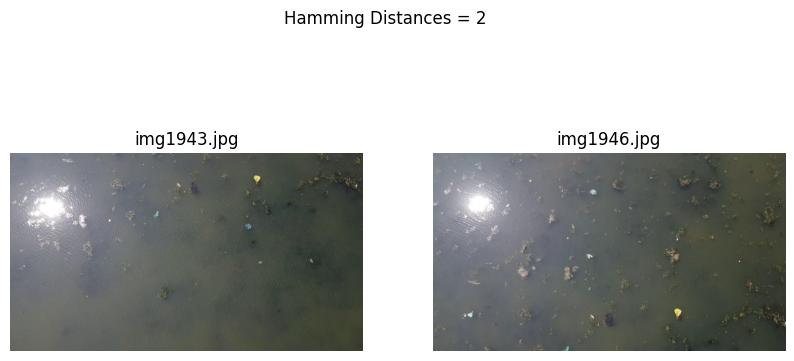

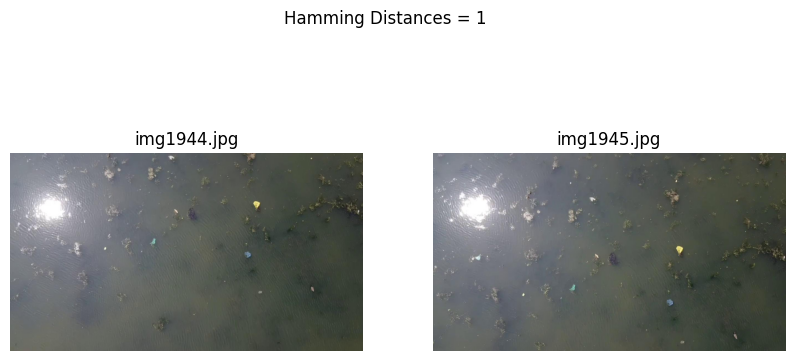

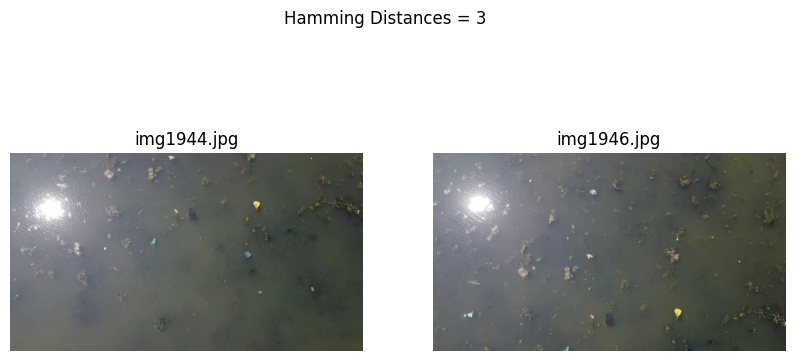

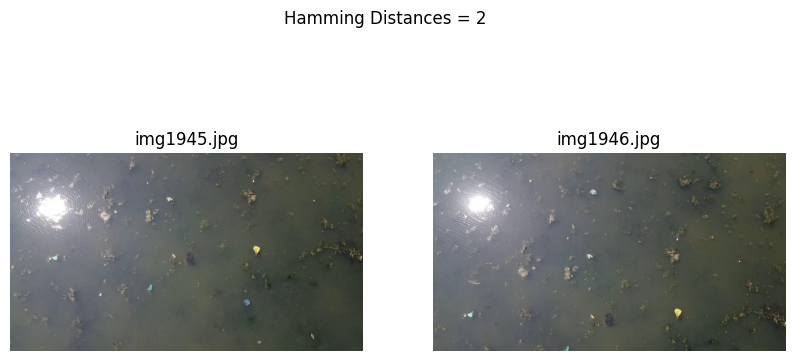

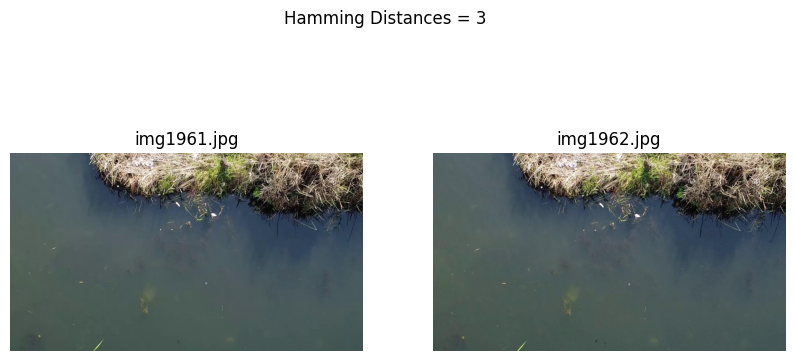

In [50]:
for a, b in pairs[-5:]:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    for k, idx in enumerate([a, b]):
        nm = df.loc[idx, "image_name"]
        ax[k].imshow(cv2.cvtColor(cv2.imread(str(IMAGES_DIR / nm)), cv2.COLOR_BGR2RGB))
        ax[k].set_title(nm); ax[k].axis("off")
    fig.suptitle(f"Hamming Distances = {dist[a, b]}")
    plt.show()

### Split (70:15:15)

In [102]:
X = np.zeros(len(df))
y = df["has_plastic"].to_numpy()
groups = df["group"].to_numpy()

- First Split (Extract Test Dataset)

In [103]:
kf_test = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)

train_val_idx, test_idx = next(kf_test.split(X, y, groups=groups))

- Second Split (Train and Validation Split)

In [104]:
kf_val = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)

# take fold 0 only, same as the first split above
train_pos, val_pos = next(kf_val.split(X[train_val_idx], y[train_val_idx], groups[train_val_idx]))

In [106]:
train_indices = train_val_idx[train_pos]
val_indices = train_val_idx[val_pos]
test_indices = test_idx

- Balance Validation and Test

StratifiedGroupKFold cuts by group, and groups have different sizes, so val and test never come out equal on their own.

The bigger side hands whole groups back to train until both sides hold the same number of images. Whole groups only, because moving a single image would leave its twin on the other side.

In [107]:
target_size = min(len(val_indices), len(test_indices))

if len(val_indices) > len(test_indices):
    bigger_name = "val"
    bigger_indices = val_indices
else:
    bigger_name = "test"
    bigger_indices = test_indices

gap = len(bigger_indices) - target_size

bigger_name, gap, target_size

('test', 21, 253)

In [108]:
# how many images each group has inside the bigger split, sorted biggest first
group_sizes = df.iloc[bigger_indices]["group"].value_counts()

# take the biggest group that still fits in the gap, repeat until the gap is closed
groups_to_move = set()

for group_id in group_sizes.index:
    if gap == 0:
        break

    size = group_sizes[group_id]

    if size <= gap:
        groups_to_move.add(group_id)
        gap = gap - size

len(groups_to_move), gap

(5, 0)

In [109]:
moved_indices = []
kept_indices = []

for i in bigger_indices:
    if groups[i] in groups_to_move:
        moved_indices.append(i)
    else:
        kept_indices.append(i)

train_indices = np.concatenate([train_indices, np.array(moved_indices, dtype=int)])

if bigger_name == "val":
    val_indices = np.array(kept_indices, dtype=int)
else:
    test_indices = np.array(kept_indices, dtype=int)

len(moved_indices), len(kept_indices)

(21, 253)

- Dictionary

In [110]:
split = {
    "train": train_indices,
    "val": val_indices,
    "test": test_indices
}

In [111]:
train_count = len(split["train"])
val_count = len(split["val"])
test_count = len(split["test"])

train_count, val_count, test_count

(1496, 253, 253)

- Leakage Check

In [113]:
for name in ["train", "val", "test"]:
    subset = df.iloc[split[name]]

    print(f"{name:6s}: {len(subset):4d} images | has_plastic {100 * subset['has_plastic'].mean():.1f}% | {subset['group'].nunique()} groups")

train : 1496 images | has_plastic 73.8% | 1271 groups
val   :  253 images | has_plastic 74.7% | 200 groups
test  :  253 images | has_plastic 74.7% | 243 groups
